# Support Vector Regressor (SVR) - House Price Prediction

This notebook trains an SVR model to predict house prices from area, bedrooms, bathrooms, age, and location score.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

## 2. Load Dataset

In [2]:
df = pd.read_csv("dataset/house_data.csv")
df.head()

,area_sqft,bedrooms,bathrooms,age_years,location_score,price
0,1360,1,3,27,2.6,231100.0
1,4272,1,2,14,3.8,572500.0
2,3592,3,2,29,3.1,525100.0
3,966,5,2,36,2.9,235600.0
4,4926,4,1,28,6.7,688300.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_sqft       500 non-null    int64  
 1   bedrooms        500 non-null    int64  
 2   bathrooms       500 non-null    int64  
 3   age_years       500 non-null    int64  
 4   location_score  500 non-null    float64
 5   price           500 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 23.6 KB


,area_sqft,bedrooms,bathrooms,age_years,location_score,price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2805.660000,2.970000,1.986000,19.086000,5.358800,429620.800000
std,1261.356268,1.452349,0.821678,11.191475,2.580609,154879.758803
min,504.000000,1.000000,1.000000,0.000000,1.000000,106400.000000
25%,1666.750000,2.000000,1.000000,10.000000,3.000000,301475.000000
50%,2930.000000,3.000000,2.000000,19.000000,5.350000,427750.000000
75%,3830.750000,4.000000,3.000000,28.000000,7.625000,550925.000000
max,4999.000000,5.000000,3.000000,39.000000,10.000000,777200.000000


## 3. Exploratory Data Analysis

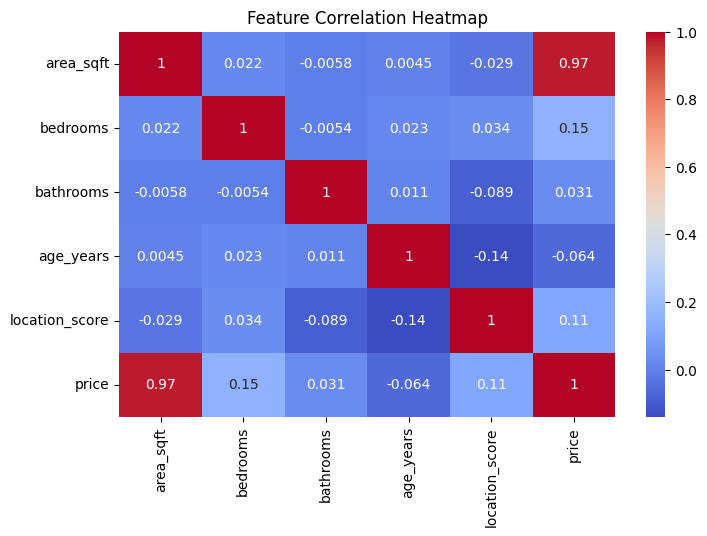

In [4]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

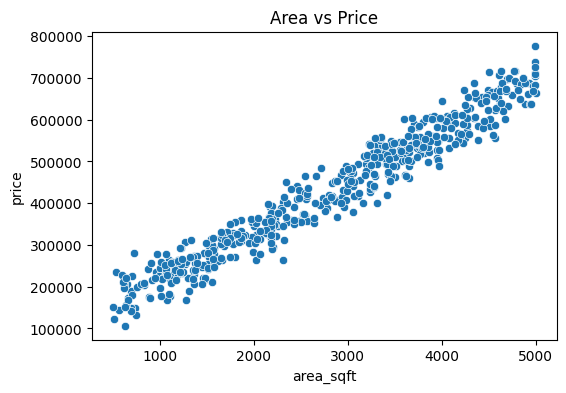

In [5]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="area_sqft", y="price", data=df)
plt.title("Area vs Price")
plt.show()

## 4. Train-Test Split

In [6]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((400, 5), (100, 5))

## 5. Feature Scaling
SVR is sensitive to feature scale, so we scale both X and y using `StandardScaler`.

In [7]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

## 6. Train SVR Model

In [8]:
model = SVR(kernel="rbf", C=10000, gamma="scale", epsilon=0.01)
model.fit(X_train_scaled, y_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## 7. Evaluate Model

In [9]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R2 Score: 0.9051
MAE: 36606.83
RMSE: 46533.08


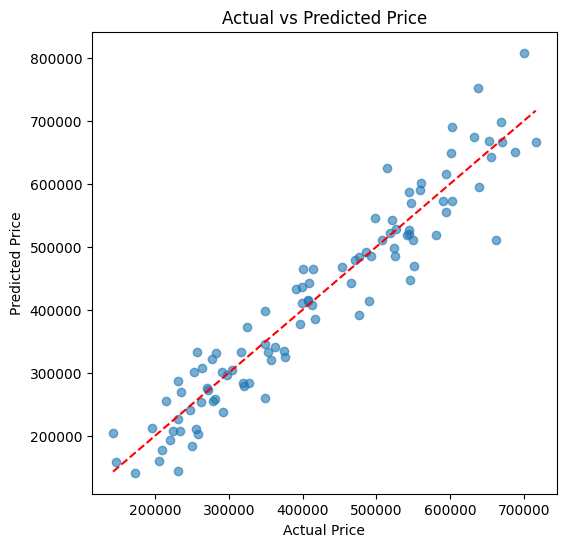

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

## 8. Save Model for Deployment
We bundle the model + both scalers + feature names into a single `.pkl` file so `app.py` can load everything in one go.

In [11]:
joblib.dump(
    {
        "model": model,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "feature_names": list(X.columns)
    },
    "svr_model.pkl"
)
print("Model saved as svr_model.pkl")

Model saved as svr_model.pkl
